In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pandas as pd

### Reweighting

An example of the training data, consisting of $N$ hadronization events (in the dataset below $N = 10,000$), is:
$$
\boldsymbol{z} = 
  \begin{pmatrix}
    \boldsymbol{z}_1 = 
    \begin{pmatrix} 
        \big\{ \texttt{idOld}^{1}, \texttt{idNew}^1, m_T^{h_1}, z^{h_1}_{\text{accept}}, z^{1, h_1}_{\text{reject}}, z^{2, h_1}_{\text{reject}}, \cdots, 									  z^{n_{h_1}, h_1}_{\text{reject}}\big\} \\
        \big\{  \texttt{idOld}^{2}, \texttt{idNew}^2, m_T^{h_2}, z^{h_2}_{\text{accept}}, z^{1, h_2}_{\text{reject}}, z^{2, h_2}_{\text{reject}}, \cdots, z^{n_{h_2}, h_2}_{\text{reject}} \big\} \\	
        \big\{ \texttt{idOld}^{3}, \texttt{idNew}^3, m_T^{h_3}, z^{h_3}_{\text{accept}}, z^{1, h_3}_{\text{reject}}, z^{2, h_3}_{\text{reject}}, \cdots, z^{n_{h_3}, h_3}_{\text{reject}} \big\} 
        \end{pmatrix}_1 \\
    \boldsymbol{z}_2 = 
    \begin{pmatrix} 
      \big\{ \texttt{idOld}^{1}, \texttt{idNew}^1, m_T^{h_1}, z^{h_1}_{\text{accept}}, z^{1, h_1}_{\text{reject}}, z^{2, h_1}_{\text{reject}}, \cdots, z^{n_{h_1}, h_1}_{\text{reject}}\big\} \\
      \vdots \\	
      \big\{ \texttt{idOld}^{4}, \texttt{idNew}^4, m_T^{h_4}, z^{h_4}_{\text{accept}}, z^{1, h_4}_{\text{reject}}, z^{2, h_4}_{\text{reject}}, \cdots, z^{n_{h_4}, h_4}_{\text{reject}} \big\} 
      \end{pmatrix}_2 \\
      \vdots \\
    \boldsymbol{z}_N = \cdots
  \end{pmatrix},
$$
$$
\boldsymbol{y}_\text{sim} = 
  \begin{pmatrix}
    \boldsymbol{y}_1 = N_{h,1} = 3\\
    \boldsymbol{y}_2 = N_{h,2} = 4 \\
    \vdots \\
    \boldsymbol{y}_N = N_{h,N} = 2
\end{pmatrix}
$$
Note that each array $\boldsymbol{z}_i$ is zero-padded to a fixed length of size $105$ and each accept-reject array is zero-padded to a fixed length of size $101$ (the maximum number of rejections is 100).

In [2]:
case = 2
#case 1: a0.72_b0.88_to_a0.68_b0.98
#case 2: a0.68_b0.98_to_a0.72_b0.88

# Load accept-reject and hadron data (for base parameterization) 
# accept_reject_base_PATH = './model_test/pgun_uubar_id_mT2_accept_reject_model_test_base_N_1e4.npy'
if case==1:
    accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
elif case==2:
    accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
pgun_accept_reject_base = np.load(accept_reject_base_PATH, mmap_mode = "r")

if case==1:
    fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_fPrel.npy'
# fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_fPrel.npy'
elif case==2:
    fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
pgun_fPrel_base = np.load(fPrel_base_PATH, mmap_mode = "r")

if case==1:
    filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_hadrons.npy'
elif case==2:
    filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
pgun_hadrons_base = np.load(filename_hadrons_base, mmap_mode="r")

if case==1:
# Load the hadron data from the target for comparison
    filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
elif case==2:
    filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_hadrons.npy'
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_hadrons.npy'
pgun_hadrons_target = np.load(filename_hadrons_target, mmap_mode="r")

if case==1:
    accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
elif case==2:
    accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.72_b0.88_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.88_bS0.88_bC0.88_bB0.88_bH0.88_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar__a0.76_b0.84_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.84_bU0.84_bS0.84_bC0.84_bB0.84_bH0.84_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
pgun_accept_reject_target = np.load(accept_reject_target_PATH, mmap_mode = "r")

In [3]:
# Check the shapes
print("Accepted and rejected z data shape:", pgun_accept_reject_base.shape)
print("fPrel data shape:", pgun_fPrel_base.shape)
print("Hadron data shape:", pgun_hadrons_base.shape)
print(pgun_accept_reject_base[0,0])
# print(pgun_hadrons_base[0])

Accepted and rejected z data shape: (100000, 200, 103)
fPrel data shape: (100000, 200, 100)
Hadron data shape: (100000, 75, 6)
[-2.          1.          0.06377188  0.44814789  0.90154823  0.0187364
  0.08701119  0.14779245  0.50050875  0.09934312  0.61947947  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.     

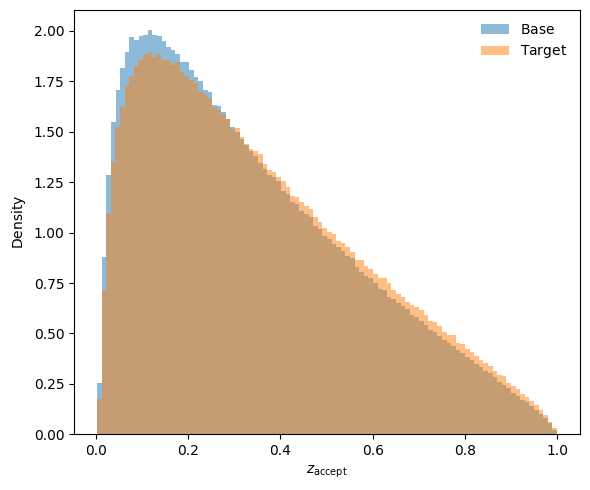

In [4]:
# Histrogram accepted z-values across all events
fig, ax = plt.subplots(1,1,figsize=(6,5))
ax.hist(pgun_accept_reject_target[:,:,3][pgun_accept_reject_target[:,:,3] > 0.0], 100, alpha = 0.5, density = True, label = r"$\mathrm{Base}$")
ax.hist(pgun_accept_reject_base[:,:,3][pgun_accept_reject_base[:,:,3] > 0.0], 100, alpha = 0.5, density = True, label = r"$\mathrm{Target}$")
ax.set_xlabel(r'$z_{\mathrm{accept}}$')
ax.set_ylabel(r'$\mathrm{Density}$')
ax.legend(frameon = False)
fig.tight_layout()

In [5]:
ids_old = pgun_accept_reject_base[:,:,0][pgun_accept_reject_base[:,:,0] > 0.0]
ids_new = pgun_accept_reject_base[:,:,1][pgun_accept_reject_base[:,:,1] > 0.0]
print(ids_old.shape)
particles, counts = np.unique(ids_old, return_counts=True)
# particles = np.array(unique_values,dtype=int)
particles = [int(p) for p in particles]
print(particles)
print(counts)
particle_types = {}



(969618,)
[1, 2]
[440681 528937]


In [6]:
Nevent = 100000
# Collect multiplicity data
mult_base = np.array([len(pgun_hadrons_base[i,:][np.abs(pgun_hadrons_base[i,:,0]) > 0.0]) for i in range(Nevent)])
mult_target = np.array([len(pgun_hadrons_target[i,:][np.abs(pgun_hadrons_target[i,:,0]) > 0.0]) for i in range(Nevent)])

3.0 37.0


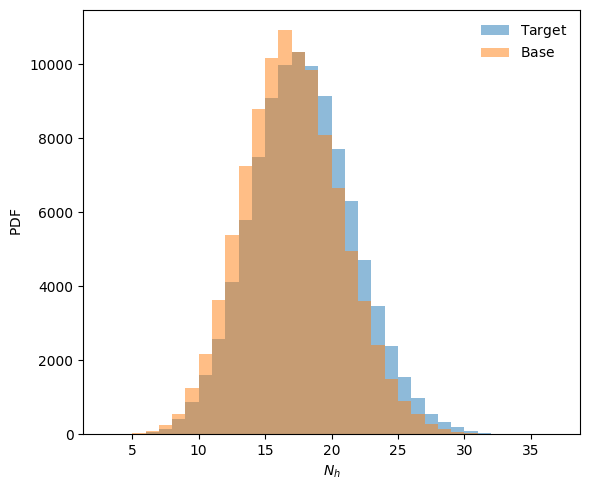

In [7]:
# Histrogram hadron multiplicity
fig, ax = plt.subplots(1,1,figsize=(6,5))

_, bins_target = np.histogram(mult_target)
_, bins_base = np.histogram(mult_base)

min_target, max_target = bins_target[0], bins_target[-1]
min_base, max_base = bins_base[0], bins_base[-1]

print(min_target, max_target)
#print(min_monash_prime, max_monash_prime)

min = np.min([min_target, min_base])
max = np.max([max_target, max_base])

bins = np.linspace(min, max, int((max - min)+1))

counts, _, _ = ax.hist(mult_target, bins, alpha = 0.5, density = False, label = r'$\mathrm{Target}$')# $(a = 0.68, b = 0.98)$')
ax.hist(mult_base, bins = bins, alpha = 0.5, density = False, label = r"$\mathrm{Base}$")
ax.set_xlabel(r'$N_h$')
ax.set_ylabel(r'$\mathrm{PDF}$')
ax.legend(frameon = False)
fig.tight_layout()

The reweighting module computes a weight array, given the base $B$ and perturbed $P$ parameterizations, according to 
$$
\boldsymbol{w} = \begin{pmatrix}
    w_1 \\
    w_2 \\
    \vdots \\
    w_N
  \end{pmatrix}, \text{ where } \\
  w_n = \prod_{i = 1}^{N_{h,n}} \left(\frac{f(z^{h_i}_\text{accept}; \{a, b\}_P)}{f(z^{h_i}_\text{accept}; \{a, b\}_{B})}\right)
  \prod_{j = 1}^{n_{h_i}} \left(\frac{\hat{f} - f(z^{j, h_i}_\text{reject}; \{a, b\}_P)}{\hat{f} - f(z^{j, h_i}_\text{reject}; \{a, b\}_{B}}\right)
$$
where $\hat{f}$ is the oversampling factor associated with the sampling of $z$ (here the over-sampling factor is 10). For each event, the accepcted and rejected $z$-values as well as the transverse mass $m_T^2 = p_x^2 + p_y^2 + m^2$ of each hadron is required to compute the event weight.

In [8]:
if case==1:
    aLund = 0.72
    bLund = 0.88
    aLundU_alt = 0.68
    bLundU_alt = 0.98
elif case ==2:
    aLund = 0.68
    bLund = 0.98
    aLundU_alt = 0.72
    bLundU_alt = 0.88


nevents = 100000
weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_a{aLundU_alt}_b{bLundU_alt}_N{nevents}.npy'
weights_loaded = np.load(weights_path)

In [9]:
# Compute the reweighting metrics (Target v1)
# print(weights_loaded.detach().numpy().shape)
# print(weights_loaded.detach().numpy())
one_minus_mu = 1. - np.sum(weights_loaded) / len(weights_loaded)
sigma_one_minus_mu = abs(1. - np.sqrt((np.sum(weights_loaded**2)/len(weights_loaded) - (np.sum(weights_loaded)/len(weights_loaded))**2)*len(weights_loaded)/(len(weights_loaded) - 1)))/np.sqrt(len(weights_loaded))
Neff = (np.sum(weights_loaded)**2 / np.sum(weights_loaded**2)) / len(weights_loaded)
print('1 - mu:', one_minus_mu, '+/-', sigma_one_minus_mu)
print('Neff:', Neff)

1 - mu: 0.007006919279573642 +/- 0.0015128262093598505
Neff: 0.7837485464360113


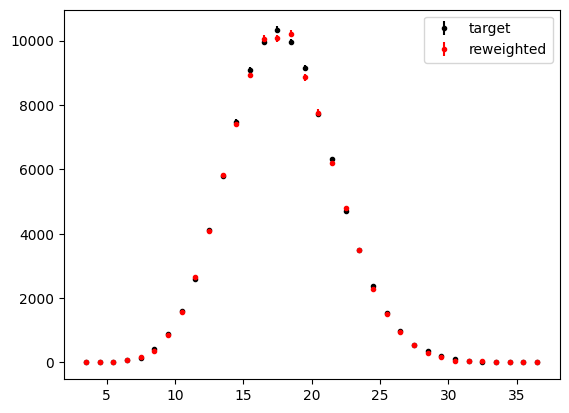

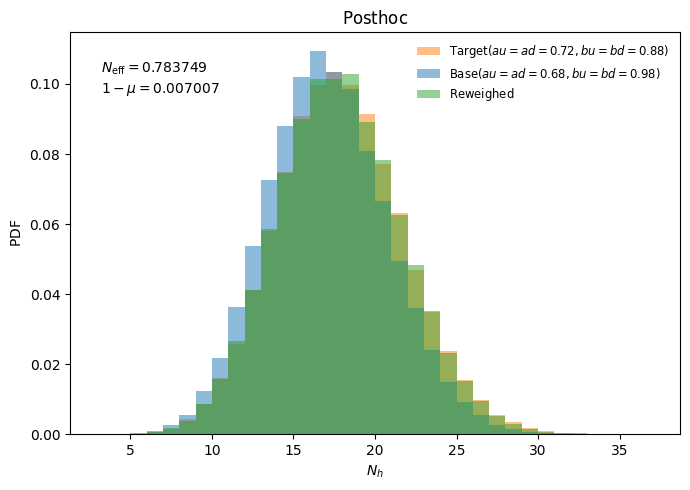

In [12]:
plt.figure()
# # print(type(mult_base[0:nevents]))
data_target = mult_target[0:nevents]
data_base = mult_base[0:nevents]

# # print(len(data_target))
# # weights_loaded
# = weights_loaded
#.detach().numpy()

# # Compute histogram and weighted errors
hist_vals_target, bin_edges_target = np.histogram(data_target, bins=bins)
bin_centers_target = 0.5 * (bin_edges_target[:-1] + bin_edges_target[1:])  # Compute bin centers

# # Compute errors (square root of sum of squared weights_loaded
# in each bin)
sum_all_weights_loaded = np.sum(weights_loaded)
errors_target = np.sqrt(hist_vals_target)
hist_weights_loaded, _ = np.histogram(data_base, bins=bins, weights=weights_loaded**2)
hist_wbase, _ = np.histogram(data_base, bins= bins, weights=weights_loaded)
errors_model = np.sqrt(hist_weights_loaded)

# hist_squared_weights_loaded
#, _ = np.histogram(data_target, bins=bins, weights_loaded
#=weights_loaded
#**2)
# # # print((hist_squared_weights_loaded
#)/sum_all_weights_loaded
#**2 )
# # # print(hist_weights_loaded
#**2/sum_all_weights_loaded
#**4 * np.sum(weights_loaded
#**2))
# errors_target = np.sqrt((hist_squared_weights_loaded
#)/sum_all_weights_loaded
#**2 + hist_weights_loaded
#**2/sum_all_weights_loaded
#**4 * np.sum(weights_loaded
#**2))plt.errorbar(bin_centers_target, hist_weights_loaded
#, yerr=errors_target, fmt=".", color="black", label="Error Bars")
plt.errorbar(bin_centers_target, hist_vals_target, yerr=errors_target, fmt=".", color="black", label="target")
plt.errorbar(bin_centers_target, hist_wbase, yerr=errors_model, fmt=".", color="red", label="reweighted")
# plt.errorbar(bin_centers_target, hist_weights_loaded
#, yerr=errors_model, fmt=".", color="blue", label="Error Bars")
plt.legend()


# Check the reweighed multiplicity historgram
fig, ax = plt.subplots(1,1,figsize=(7,5))

ax.hist(mult_target[0:nevents], bins = bins, alpha = 0.5, label = r"$\mathrm{Target}$"+ rf"$(au = ad = {aLundU_alt}, bu = bd = {bLundU_alt})$", color = 'tab:orange', density = True)
ax.hist(mult_base[0:nevents], bins = bins, alpha = 0.5, label = r'$\mathrm{Base}$' + rf'$(au = ad = {aLund}, bu = bd = {bLund})$', color = 'tab:blue', density = True)
ax.hist(mult_base[0:nevents], bins = bins, weights = weights_loaded, alpha = 0.5, label = r"$\mathrm{Reweighed}$", color = 'tab:green', density = True)

# ax.errorbar(bin_centers_target, hist_vals_target, yerr=errors_target, fmt=".", color="black", label="Error Bars")


# Place the rewighting metrics on the upper left corner of the figure
ax.text(0.05, 0.9, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10, transform = ax.transAxes)
ax.text(0.05, 0.85, rf'$1 - \mu = {one_minus_mu:3f}$', fontsize = 10, transform = ax.transAxes)

#ax.text(1.0, 0.10, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10)
#ax.text(1.0, 0.10, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10)
#ax.text(1.0, 0.095, rf'$1 - \mu = {one_minus_mu:3f}$', fontsize = 10)

ax.set_xlabel(r'$N_h$')
ax.set_ylabel(r'$\mathrm{PDF}$')
ax.legend(frameon = False, fontsize = 'small')
ax.set_title(r'$\mathrm{Posthoc}$')
fig.tight_layout()

# print(hist_vals)
# print(hist_vals_target)

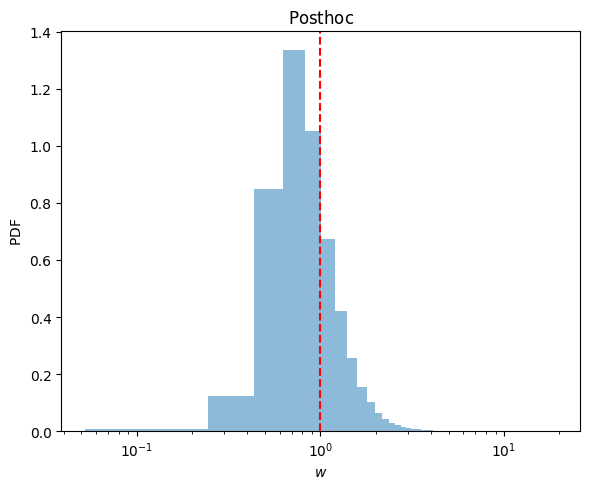

In [11]:
# Check the distribution of weights (Target v1)
fig, ax = plt.subplots(1,1,figsize=(6,5))
ax.hist(weights_loaded, 100, alpha = 0.5, density=True)
ax.set_xlabel(r'$w$')
ax.set_ylabel(r'$\mathrm{PDF}$')
ax.set_xscale('log')
ax.vlines(1., 0., 2., color = 'red', linestyle = '--', transform = ax.get_xaxis_transform())
ax.set_title(r'$\mathrm{Posthoc}$')
fig.tight_layout()